<a href="https://colab.research.google.com/github/ShubhamSahu-2005/llm-lab/blob/main/ML_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')



In [102]:
df=pd.read_csv('/content/insurance.csv')
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [103]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


#EDA


In [104]:
df.shape

(1338, 7)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [106]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [107]:
df.columns.to_list()

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

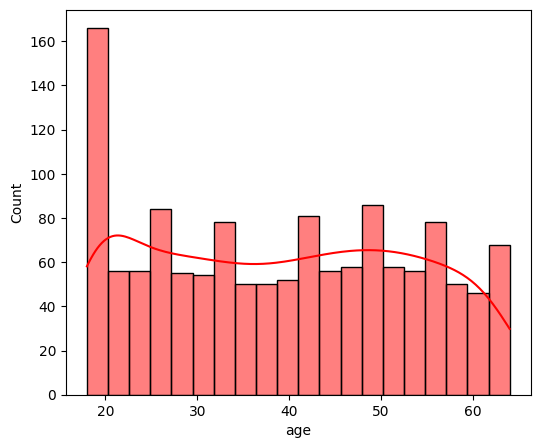

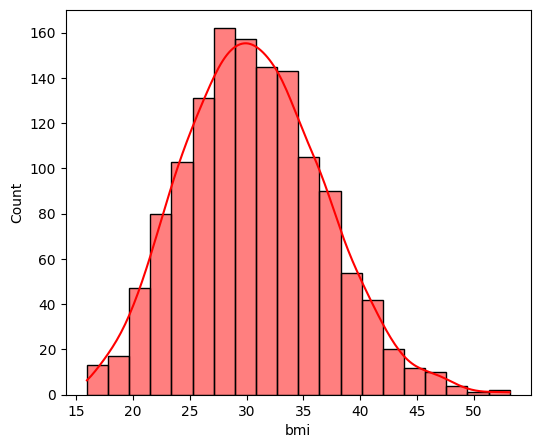

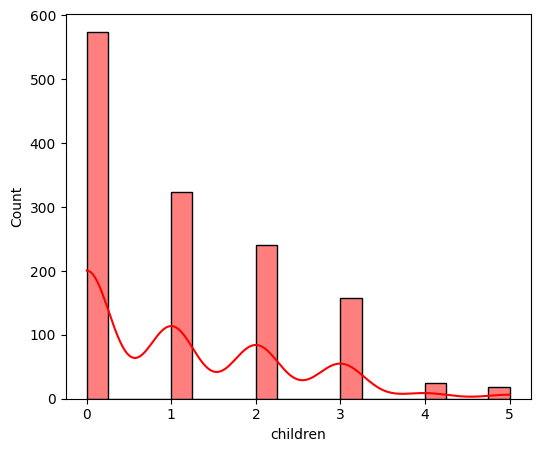

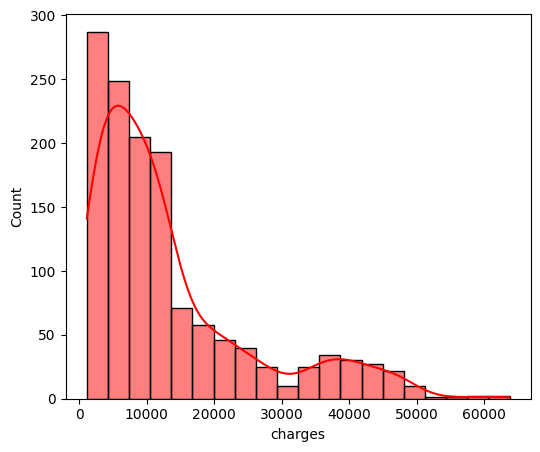

In [108]:

numeric_columns=['age',  'bmi', 'children',  'charges']
for col in numeric_columns:
  plt.figure(figsize=(6,5))
  sns.histplot(df[col],kde=True,bins=20,color='red')


<Axes: xlabel='children', ylabel='count'>

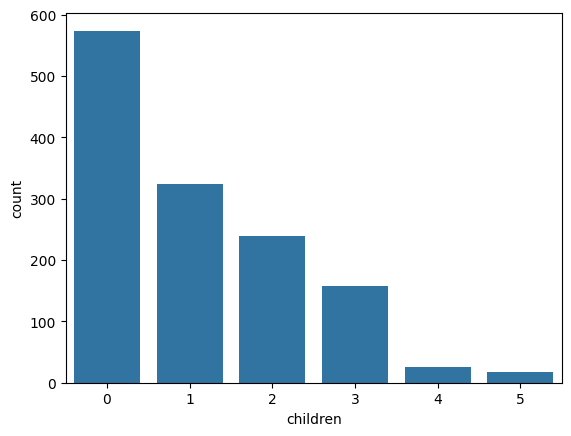

In [109]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

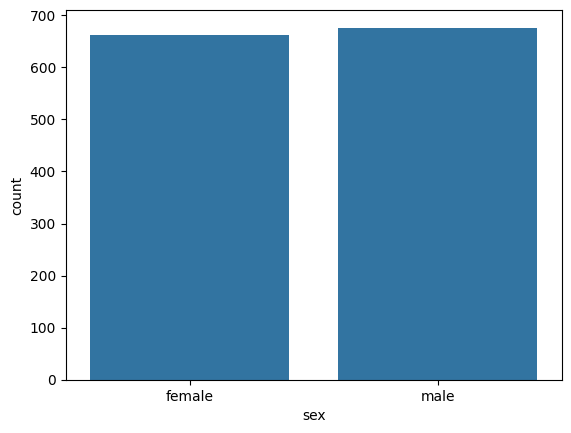

In [110]:
sns.countplot(x=df['sex'])

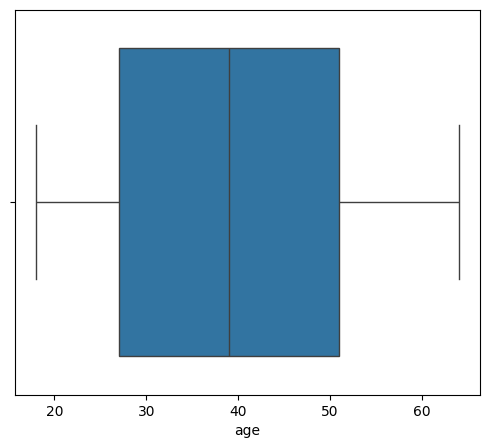

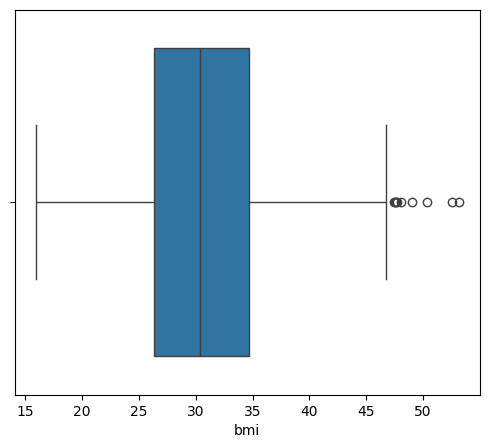

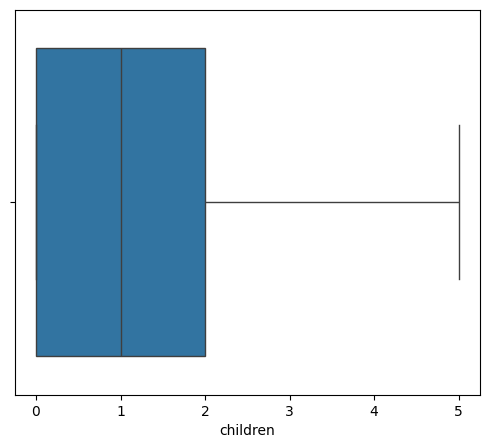

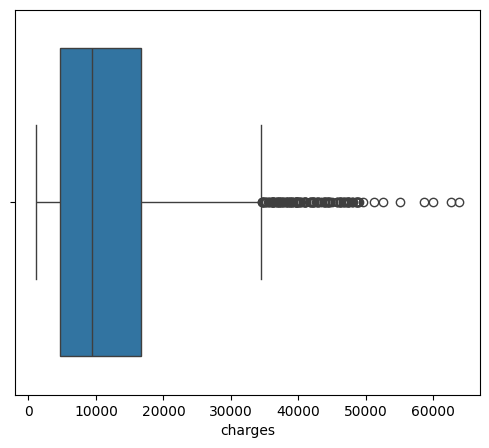

In [111]:
for col in numeric_columns:
  plt.figure(figsize=(6,5))
  sns.boxplot(x=df[col])

<Axes: >

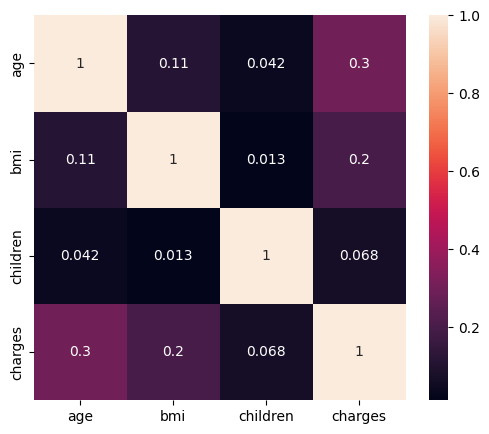

In [112]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)


# Data Cleaning ANd Preprocessing


In [113]:
df_cleaned=df.copy()
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [114]:
df_cleaned.shape

(1338, 7)

In [115]:
df_cleaned.duplicated().sum()
duplicated_value=df_cleaned[df_cleaned.duplicated()]
print(duplicated_value)

     age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631


In [116]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(1337, 7)

In [117]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [118]:
df_pure=df.copy()
df_pure.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [119]:
df_pure['sex'].unique()


array(['female', 'male'], dtype=object)

In [120]:
df_pure.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [121]:
df_pure = df.copy()
df_pure['sex'] = df_pure['sex'].str.strip().map({'male': 0, 'female': 1})
df_pure.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [122]:
df_pure['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [123]:
df_pure['smoker']=df_pure['smoker'].map({
    "no":0,
    "yes":1

})
df_pure.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [124]:
df_pure.rename(columns={
    'sex':"is_female",
    "smoker":"is_smoker"
},inplace=True)
df_pure.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [125]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [126]:
df_pure=pd.get_dummies(df_pure,columns=['region'],drop_first=True)


In [127]:
df_pure.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [128]:
df_pure

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


In [133]:
df_pure.duplicated().sum()
print(df_pure[df_pure.duplicated()])
df_pure.shape
df_pure.drop_duplicates(inplace=True)
df_pure.shape

     age  is_female    bmi  children  is_smoker    charges  region_northwest  \
581   19          0  30.59         0          0  1639.5631              True   

     region_southeast  region_southwest  
581             False             False  


(1337, 9)

#Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

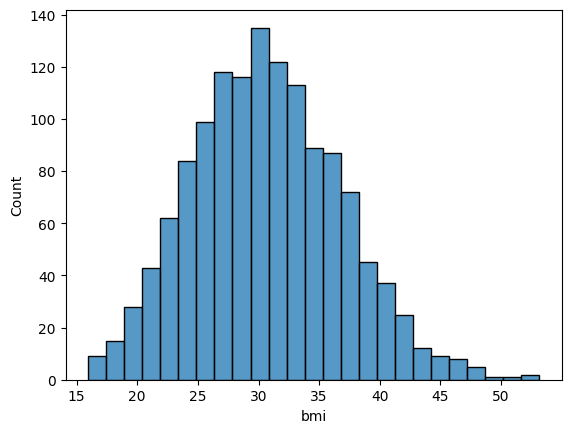

In [136]:
sns.histplot(df_pure['bmi'])

In [138]:
df_pure['bmi_category']=pd.cut(
    df_pure['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['Underweight','Normal','Overweight','Obese']


)

In [139]:
df_pure

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,True,Overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,Obese
2,28,0,33.000,3,0,4449.46200,False,True,False,Obese
3,33,0,22.705,0,0,21984.47061,True,False,False,Normal
4,32,0,28.880,0,0,3866.85520,True,False,False,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,Obese
1334,18,1,31.920,0,0,2205.98080,False,False,False,Obese
1335,18,1,36.850,0,0,1629.83350,False,True,False,Obese
1336,21,1,25.800,0,0,2007.94500,False,False,True,Overweight


In [140]:
df_pure=pd.get_dummies(df_pure,columns=['bmi_category'],drop_first=True)

In [141]:
df_pure=df_pure.astype(int)

In [142]:
df_pure.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [143]:
print(df_pure.columns.to_list())

['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese']


In [144]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()
df_pure[cols]=scaler.fit_transform(df_pure[cols])

In [148]:
df_pure.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [150]:
from scipy.stats import pearsonr

scaled_features=['age', 'is_female', 'bmi', 'children', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese']
correlations={
    feature:pearsonr(df_pure[feature],df_pure['charges'])[0]
    for feature in scaled_features
}
correlation_df=pd.DataFrame(list(correlations.items()),columns=['Feature','Pearsons Correlations Coefficient'])
correlation_df.sort_values(by='Pearsons Correlations Coefficient',ascending=False)

,Feature,Pearsons Correlations Coefficient
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_Obese,0.197660
2,bmi,0.196236
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
1,is_female,-0.058046
8,bmi_category_Normal,-0.105656


In [152]:
cat_features=['is_female','is_smoker','region_northwest','region_southeast','region_southwest','bmi_category_Normal','bmi_category_Overweight','bmi_category_Obese']


In [153]:
from scipy.stats import chi2_contingency
alpha=0.05
df_pure['charges_bin']=pd.qcut(df_pure['charges'],q=4,labels=False)
chi2_results={}
for col in cat_features:
  contingency_table=pd.crosstab(df_pure[col],df_pure['charges_bin'])
  chi2_stat,p_val,_,_=chi2_contingency(contingency_table)
  desicion='Reject null(Keep Feature)' if p_val<alpha else 'Accept Null (Drop Feature)'
  chi2_results[col]={
      'chi2_statistics':chi2_stat,
      'p_value':p_val,
      'Decision':desicion
  }
chi2_df=pd.DataFrame(chi2_results).T
chi2_df=chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistics,p_value,Decision
is_smoker,848.219178,0.0,Reject null(Keep Feature)
region_southeast,15.998167,0.001135,Reject null(Keep Feature)
is_female,10.258784,0.01649,Reject null(Keep Feature)
bmi_category_Obese,7.654464,0.05372,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Normal,4.263673,0.234364,Accept Null (Drop Feature)
bmi_category_Overweight,4.201575,0.240504,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [155]:
final_df = df_pure[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese']]

In [156]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0
